# Atom-Level Transformer — Global **Spatiotemporal** Molecular Context


The old atom-level transformer let each atom see only its **21-atom neighbourhood**. the atom moves on the basis of all the others. We therefore add a **second cross-attention**
onto an encoding of the **whole molecule**.

In this version the global branch is **spatiotemporal**: instead of a single snapshot `(138, 9)` it now
reads a temporal window `(T_WINDOW, 138, 9)` — every atom at every recent time step. A dedicated
**Global Spatiotemporal Encoder** lets any atom-time attend to any other atom-time (long-range in both
space and time), and the decoder fuses this with the fine-grained **local** dynamics through cross-attention.

* **Local encoder**  → neighbourhood of the target atom over time (fine-grained motion)
* **Global spatiotemporal encoder** → the whole molecule over `T_WINDOW` steps (global evolution)
* **Decoder** → causal self-attention → cross-attn to **local** → cross-attn to **global** → output

A single flag `use_global` turns the global path on/off for a clean ablation. We also visualise the
**spatiotemporal attention** (which atoms, at which past step) and provide a parametric sweep for Table 1.

## 0. Setup, data loading, scaling & split  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random, os


def set_all_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
set_all_seeds(42)

In [ ]:
# Edit this if required
DATA_DIR = '/content/drive/MyDrive/'

coordinates_df = pd.read_csv(DATA_DIR+'coordinates.csv', header=None, index_col=False, sep=';')

forces_raw = pd.read_csv(DATA_DIR+'forces.csv', header=None, index_col=False, sep=None, engine='python')
forces_df  = forces_raw[0].str.split('\t', expand=True).apply(pd.to_numeric, errors='coerce')

vels_raw   = pd.read_csv(DATA_DIR+'velocity.csv', header=None, index_col=False, sep=None, engine='python')
velocities_df = vels_raw[0].str.split('\t', expand=True).apply(pd.to_numeric, errors='coerce')

print('coords', coordinates_df.shape, '| forces', forces_df.shape, '| vels', velocities_df.shape)

coords (50001, 415) | forces (50001, 415) | vels (50001, 415)


In [ ]:
NUM_ATOMS = 138          # atoms in the molecule
F         = 9            # features per atom: x,y,z, vx,vy,vz, fx,fy,fz

# drop the timestep column, reshape to (T, atoms, xyz), concat features
coords = coordinates_df.iloc[:, 1:].values.reshape(-1, NUM_ATOMS, 3)
vels   = velocities_df.iloc[:, 1:].values.reshape(-1, NUM_ATOMS, 3)
forces = forces_df.iloc[:, 1:].values.reshape(-1, NUM_ATOMS, 3)
features = np.concatenate([coords, vels, forces], axis=-1)   # (T, 138, 9)
print('features', features.shape)

# split 70 / 15 / 15
N = len(features)
train_end = int(N*0.70)
val_end   = int(N*0.85)

# StandardScaler fit on TRAIN ONLY (no leakage from future frames)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(features[:train_end].reshape(-1, F))

def scale_data(data):
    T = data.shape[0]
    return scaler.transform(data.reshape(-1, F)).reshape(T, NUM_ATOMS, F).astype('float32')

features_scaled = scale_data(features)
train_feat = features_scaled[:train_end]
val_feat   = features_scaled[train_end:val_end]
test_feat  = features_scaled[val_end:]
print(f'Train {train_feat.shape} | Val {val_feat.shape} | Test {test_feat.shape}')

features (50001, 138, 9)
Train (35000, 138, 9) | Val (7500, 138, 9) | Test (7501, 138, 9)


## 1. Transformer building blocks  


In [ ]:
def positional_encoding(length, depth):
    depth = depth/2
    positions = np.arange(length)[:, np.newaxis]
    depths    = np.arange(depth)[np.newaxis, :]/depth
    angle_rads = positions * (1/(10000**depths))
    pos = np.concatenate([np.sin(angle_rads), np.cos(angle_rads)], axis=-1)
    return tf.cast(pos, tf.float32)

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, d_model, **kw):
        super().__init__(**kw)
        self.d_model = d_model
        self.projection = tf.keras.layers.Dense(d_model)
        self.pos_encoding = positional_encoding(2048, d_model)
    def call(self, x):
        seq_len = tf.shape(x)[1]
        x = self.projection(x)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        return x + self.pos_encoding[tf.newaxis, :seq_len, :]

class BaseAttention(tf.keras.layers.Layer):
    def __init__(self, **kw):
        super().__init__()
        self.mha = tf.keras.layers.MultiHeadAttention(**kw)
        self.layernorm = tf.keras.layers.LayerNormalization()
        self.add = tf.keras.layers.Add()

class CrossAttention(BaseAttention):
    last_attn_scores = None
    def call(self, x, context):
        out, scores = self.mha(query=x, key=context, value=context,
                               return_attention_scores=True)
        # store scores only in eager mode (visualization); skip inside the
        # compiled fit() graph to avoid 'tensor out of scope' errors on Keras 3
        if tf.executing_eagerly():
            self.last_attn_scores = scores
        return self.layernorm(self.add([x, out]))

class GlobalSelfAttention(BaseAttention):
    def call(self, x):
        out = self.mha(query=x, value=x, key=x)
        return self.layernorm(self.add([x, out]))

class CausalSelfAttention(BaseAttention):
    def call(self, x):
        out = self.mha(query=x, value=x, key=x, use_causal_mask=True)
        return self.layernorm(self.add([x, out]))

class FeedForward(tf.keras.layers.Layer):
    def __init__(self, d_model, dff, dropout_rate=0.1):
        super().__init__()
        self.seq = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model),
            tf.keras.layers.Dropout(dropout_rate)])
        self.add = tf.keras.layers.Add()
        self.layer_norm = tf.keras.layers.LayerNormalization()
    def call(self, x):
        return self.layer_norm(self.add([x, self.seq(x)]))

class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.self_attention = GlobalSelfAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)
    def call(self, x):
        return self.ffn(self.self_attention(x))

class Encoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.pos_embedding = PositionalEmbedding(d_model=d_model)
        self.enc_layers = [EncoderLayer(d_model=d_model, num_heads=num_heads, dff=dff,
                                        dropout_rate=dropout_rate) for _ in range(num_layers)]
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
    def call(self, x):
        x = self.dropout(self.pos_embedding(x))
        for layer in self.enc_layers:
            x = layer(x)
        return x

def mse_loss(y_true, y_pred):  return tf.reduce_mean(tf.square(y_true - y_pred))
def mae_metric(y_true, y_pred): return tf.reduce_mean(tf.abs(y_true - y_pred))
print('Base classes defined.')

Base classes defined.


## 2. Global-context data pipeline (spatiotemporal)

An atom's next-step displacement is driven by the force field of the *entire* molecule **as it evolves**,
not just where it sits at one instant. So each training sample now carries a temporal window of the whole
molecule, letting the global encoder learn how all atoms move together.

Each sample is a triple:

| tensor  | shape                 | meaning                                                        |
|---------|-----------------------|----------------------------------------------------------------|
| `x_enc` | `(T_WINDOW, 189)`     | local neighbourhood (21 atoms × 9) over `T_WINDOW` steps        |
| `x_dec` | `(1, 9)`              | current state of the target atom `a` at time `t`               |
| `x_glob`| `(T_WINDOW, 138, 9)`  | **whole molecule over the last `T_WINDOW` steps (spatiotemporal)** |
| `y`     | `(9,)`                | target delta = state(t+1) − state(t)                           |

The same dataset feeds both models — when `use_global=False` the model ignores `x_glob`, giving a
controlled local-only vs local+global ablation.

In [ ]:
def make_global_dataset(features_arr, t_window, spatial_window, batch_size,
                        n_atoms_sample=3, shuffle=False):
    N, A, Feat = features_arr.shape
    S = spatial_window
    ATOMS_IN = 2*S + 1
    padded = np.pad(features_arr, ((0,0),(S,S),(0,0)), mode='edge').astype(np.float32)

    def generator():
        timesteps = np.arange(t_window, N-1)
        if shuffle:
            np.random.shuffle(timesteps)
        for t in timesteps:
            glob = features_arr[t-t_window:t].astype(np.float32)      # (T_WINDOW, 138, 9) whole molecule over time
            atoms = np.random.choice(A, size=n_atoms_sample, replace=False)
            for a in atoms:
                neigh = padded[t-t_window:t, a:a+2*S+1, :]
                x_enc = neigh.reshape(t_window, -1).astype(np.float32) # (T, 189)
                x_dec = features_arr[t, a, :].reshape(1, -1).astype(np.float32)     # (1, 9)
                y     = (features_arr[t+1, a, :] - features_arr[t, a, :]).astype(np.float32)
                yield (x_enc, x_dec, glob), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            (tf.TensorSpec(shape=(t_window, ATOMS_IN*Feat), dtype=tf.float32),
             tf.TensorSpec(shape=(1, Feat),                 dtype=tf.float32),
             tf.TensorSpec(shape=(t_window, A, Feat),       dtype=tf.float32)),   # x_glob now (T_WINDOW, 138, 9)
            tf.TensorSpec(shape=(Feat,), dtype=tf.float32)))
    if shuffle:
        ds = ds.shuffle(2000)
    return ds.batch(batch_size).repeat().prefetch(tf.data.AUTOTUNE)


def build_datasets(t_window, spatial_window, batch_size=128, n_atoms_sample=3):
    tr = make_global_dataset(train_feat, t_window, spatial_window, batch_size, n_atoms_sample, shuffle=True)
    va = make_global_dataset(val_feat,   t_window, spatial_window, batch_size, n_atoms_sample)
    te = make_global_dataset(test_feat,  t_window, spatial_window, batch_size, n_atoms_sample)
    n_tr = (len(train_feat)-t_window)*n_atoms_sample // batch_size
    n_va = (len(val_feat)  -t_window)*n_atoms_sample // batch_size
    n_te = (len(test_feat) -t_window)*n_atoms_sample // batch_size
    return tr, va, te, n_tr, n_va, n_te

# sanity check with default windows
SPATIAL_WINDOW = 10
T_WINDOW       = 5
train_ds, val_ds, test_ds, n_tr, n_va, n_te = build_datasets(T_WINDOW, SPATIAL_WINDOW)
for (xe, xd, xg), y in train_ds.take(1):
    print('x_enc', xe.shape, '| x_dec', xd.shape, '| x_glob', xg.shape, '| y', y.shape)  # x_glob (B, T, 138, 9)
    print(f'y mean = {y.numpy().mean():.5f}  (should be ~0)')
print(f'steps/epoch: train={n_tr} val={n_va} test={n_te}')

x_enc (128, 5, 189) | x_dec (128, 1, 9) | x_glob (128, 5, 138, 9) | y (128, 9)
y mean = -0.00179  (should be ~0)
steps/epoch: train=820 val=175 test=175


## 3. Dual-context decoder & spatiotemporal global encoder

The local encoder is unchanged. The global branch becomes a **Global Spatiotemporal Encoder**: it
projects `(T_WINDOW, 138, 9)`, adds **separate time and atom positional encodings**, flattens to
`T_WINDOW*138` atom-time tokens, and self-attends over all of them. The decoder cross-attends to this
representation. The `use_global` flag turns the whole branch on/off without changing anything else.

In [ ]:
# ---------- spatiotemporal positional embedding + global encoder ----------
class SpatioTemporalPositionalEmbedding(tf.keras.layers.Layer):
    """(B, T, A, F) -> (B, T*A, d) with SEPARATE time and atom positional encodings."""
    def __init__(self, d_model, max_time=64, max_atoms=1024, **kw):
        super().__init__(**kw)
        self.d_model    = d_model
        self.projection = tf.keras.layers.Dense(d_model)
        self.time_pe    = positional_encoding(max_time,  d_model)   # position in time
        self.atom_pe    = positional_encoding(max_atoms, d_model)   # position = atom index
    def call(self, x):                                              # x: (B, T, A, F)
        T = tf.shape(x)[1]; A = tf.shape(x)[2]
        x = self.projection(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))   # (B,T,A,d)
        x = x + self.time_pe[tf.newaxis, :T, tf.newaxis, :] \
              + self.atom_pe[tf.newaxis, tf.newaxis, :A, :]         # add time + space positions
        return tf.reshape(x, (tf.shape(x)[0], T*A, self.d_model))   # flatten to (B, T*A, d)

class GlobalSpatioTemporalEncoder(tf.keras.layers.Layer):
    """Self-attention over all atom-time tokens: any atom at any step attends to any other."""
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.pos = SpatioTemporalPositionalEmbedding(d_model)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.enc_layers = [EncoderLayer(d_model=d_model, num_heads=num_heads, dff=dff,
                                        dropout_rate=dropout_rate) for _ in range(num_layers)]
    def call(self, x):                                             # (B, T, A, F)
        x = self.dropout(self.pos(x))                             # (B, T*A, d)
        for layer in self.enc_layers:
            x = layer(x)
        return x                                                  # (B, T*A, d)

# ---------- decoder (dual cross-attention: local + global) ----------
class DualDecoderLayer(tf.keras.layers.Layer):
    def __init__(self, *, d_model, num_heads, dff, dropout_rate=0.1, use_global=True):
        super().__init__()
        self.use_global = use_global
        self.causal_self_attention = CausalSelfAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.cross_local  = CrossAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        if use_global:
            self.cross_global = CrossAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout_rate)
        self.ffn = FeedForward(d_model, dff)
        self.last_attn_local = None
        self.last_attn_global = None
    def call(self, x, local_ctx, global_ctx=None):
        x = self.causal_self_attention(x=x)
        x = self.cross_local(x=x, context=local_ctx)
        if tf.executing_eagerly():
            self.last_attn_local = self.cross_local.last_attn_scores
        if self.use_global:
            x = self.cross_global(x=x, context=global_ctx)
            if tf.executing_eagerly():
                self.last_attn_global = self.cross_global.last_attn_scores
        return self.ffn(x)

class DualDecoder(tf.keras.layers.Layer):
    def __init__(self, *, num_layers, d_model, num_heads, dff, dropout_rate=0.1, use_global=True):
        super().__init__()
        self.use_global = use_global
        self.pos_embedding = PositionalEmbedding(d_model=d_model)
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.dec_layers = [DualDecoderLayer(d_model=d_model, num_heads=num_heads, dff=dff,
                           dropout_rate=dropout_rate, use_global=use_global) for _ in range(num_layers)]
        self.last_attn_local = None
        self.last_attn_global = None
    def call(self, x, local_ctx, global_ctx=None):
        x = self.dropout(self.pos_embedding(x))
        for layer in self.dec_layers:
            x = layer(x, local_ctx, global_ctx)
        if tf.executing_eagerly():
            self.last_attn_local  = self.dec_layers[-1].last_attn_local
            self.last_attn_global = self.dec_layers[-1].last_attn_global
        return x

# ---------- full model: global branch is spatiotemporal ----------
class AtomEncoderDecoderGlobal(tf.keras.Model):
    def __init__(self, *, num_layers, d_model, num_heads, dff,
                 output_dim=9, dropout_rate=0.1, use_global=True):
        super().__init__()
        self.use_global    = use_global
        self.local_encoder = Encoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                                     dff=dff, dropout_rate=dropout_rate)
        if use_global:
            self.global_encoder = GlobalSpatioTemporalEncoder(num_layers=num_layers, d_model=d_model,
                                     num_heads=num_heads, dff=dff, dropout_rate=dropout_rate)
        self.decoder = DualDecoder(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                                   dff=dff, dropout_rate=dropout_rate, use_global=use_global)
        self.output_layer = tf.keras.layers.Dense(output_dim)
    def call(self, inputs, training=False):
        x_enc, x_dec, x_glob = inputs                                          # x_glob: (B, T, 138, 9)
        local_ctx  = self.local_encoder(x_enc, training=training)             # (B, T, d)
        global_ctx = self.global_encoder(x_glob, training=training) if self.use_global else None  # (B, T*138, d)
        dec_out = self.decoder(x_dec, local_ctx, global_ctx)[:, 0, :]         # (B, d)
        return self.output_layer(dec_out)                                     # (B, 9)


def build_model(use_global, num_layers=1, d_model=32, num_heads=2, dff=64,
                dropout_rate=0.1, lr=1e-4, sample_ds=None):
    set_all_seeds(42)  # same init for a fair local-vs-global comparison
    m = AtomEncoderDecoderGlobal(num_layers=num_layers, d_model=d_model, num_heads=num_heads,
                                 dff=dff, output_dim=9, dropout_rate=dropout_rate, use_global=use_global)
    for (xe, xd, xg), _ in sample_ds.take(1):      # build the graph
        m((xe, xd, xg), training=False)
    m.compile(loss=mse_loss, optimizer=tf.keras.optimizers.Adam(lr), metrics=[mae_metric])
    return m

print('Spatiotemporal-global dual-context model defined.')

Spatiotemporal-global dual-context model defined.


## 4. Ablation training — *local-only* vs *local + global*




Same data, same hyper-parameters, same seed => the only difference is the global cross-attention.


In [ ]:
EPOCHS = 30

def train_model(model, train_ds, val_ds, n_tr, n_va, epochs=EPOCHS, tag='model'):
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                          restore_best_weights=True, verbose=1)
    hist = model.fit(train_ds, validation_data=val_ds,
                     epochs=epochs, steps_per_epoch=n_tr, validation_steps=n_va,
                     callbacks=[es], verbose=1)
    model.save_weights(f'{tag}.weights.h5')
    print(f'[{tag}] saved -> {tag}.weights.h5')
    return hist

In [ ]:
# ---- (a) LOCAL-ONLY baseline (use_global=False) ----
model_local = build_model(use_global=False, sample_ds=train_ds)
print(f'LOCAL-only params : {model_local.count_params():,}')
hist_local  = train_model(model_local, train_ds, val_ds, n_tr, n_va, tag='atom_local')

LOCAL-only params : 40,649
Epoch 1/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 82s 90ms/step - loss: 0.3208 - mae_metric: 0.3957 - val_loss: 0.1429 - val_mae_metric: 0.1980
Epoch 2/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - loss: 0.1492 - mae_metric: 0.2537 - val_loss: 0.1419 - val_mae_metric: 0.1917
Epoch 3/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 70s 86ms/step - loss: 0.1237 - mae_metric: 0.2219 - val_loss: 0.1243 - val_mae_metric: 0.1838
Epoch 4/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 70s 85ms/step - loss: 0.0894 - mae_metric: 0.1958 - val_loss: 0.0817 - val_mae_metric: 0.1645
Epoch 5/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 81s 99ms/step - loss: 0.0694 - mae_metric: 0.1706 - val_loss: 0.0680 - val_mae_metric: 0.1521
Epoch 6/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - loss: 0.0609 - mae_metric: 0.1575 - val_loss: 0.0578 - val_mae_metric: 0.1410
Epoch 7/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 73s 89ms/step - loss: 0.0539 - mae_metric: 0.1470 - val_loss: 0.0512 - val_mae_metric: 0.1324
Epoch 8/30
820/820 ━━━━━━━━━━━━━━━━

In [ ]:
# ---- (b) LOCAL + GLOBAL (use_global=True) ----
model_global = build_model(use_global=True, sample_ds=train_ds)
print(f'LOCAL+GLOBAL params: {model_global.count_params():,}')
hist_global  = train_model(model_global, train_ds, val_ds, n_tr, n_va, tag='atom_global')

LOCAL+GLOBAL params: 62,185
Epoch 1/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 176s 197ms/step - loss: 0.2745 - mae_metric: 0.3578 - val_loss: 0.1451 - val_mae_metric: 0.1997
Epoch 2/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 160s 195ms/step - loss: 0.1275 - mae_metric: 0.2278 - val_loss: 0.1240 - val_mae_metric: 0.1852
Epoch 3/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 159s 194ms/step - loss: 0.0935 - mae_metric: 0.1975 - val_loss: 0.0835 - val_mae_metric: 0.1679
Epoch 4/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 161s 197ms/step - loss: 0.0747 - mae_metric: 0.1760 - val_loss: 0.0693 - val_mae_metric: 0.1514
Epoch 5/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 161s 197ms/step - loss: 0.0639 - mae_metric: 0.1612 - val_loss: 0.0616 - val_mae_metric: 0.1407
Epoch 6/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 161s 196ms/step - loss: 0.0571 - mae_metric: 0.1512 - val_loss: 0.0533 - val_mae_metric: 0.1352
Epoch 7/30
820/820 ━━━━━━━━━━━━━━━━━━━━ 160s 195ms/step - loss: 0.0519 - mae_metric: 0.1433 - val_loss: 0.0495 - val_mae_metric: 0.1299
Epoch 8/30
820/820 ━

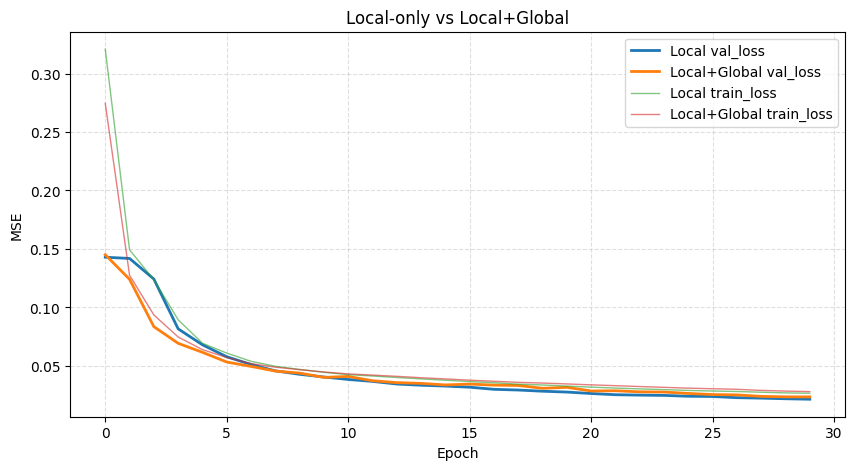

In [ ]:
# ---- training curves (saved as 300 dpi jpg, per the rules) ----
def plot_two(h1, h2, l1, l2, fname):
    plt.figure(figsize=(10,5))
    plt.plot(h1.history['val_loss'], linewidth=2, label=f'{l1} val_loss')
    plt.plot(h2.history['val_loss'], linewidth=2, label=f'{l2} val_loss')
    plt.plot(h1.history['loss'], linewidth=1, alpha=.6, label=f'{l1} train_loss')
    plt.plot(h2.history['loss'], linewidth=1, alpha=.6, label=f'{l2} train_loss')
    plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Local-only vs Local+Global')
    plt.legend(); plt.grid(True, ls='--', alpha=.4)
    plt.savefig(fname, dpi=300, bbox_inches='tight'); plt.show()

plot_two(hist_local, hist_global, 'Local', 'Local+Global', 'ablation_curves.jpg')

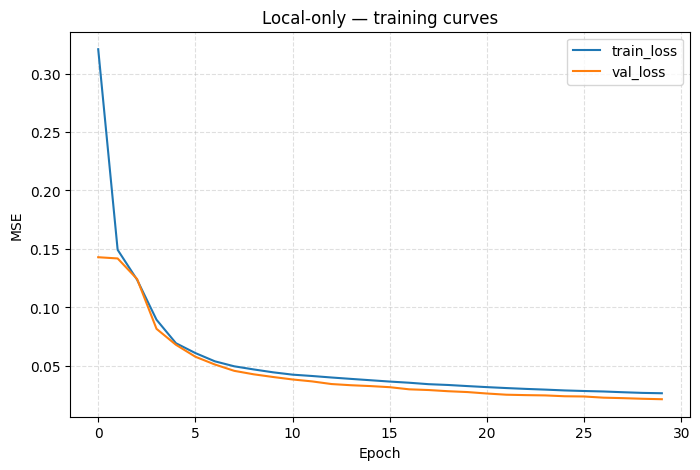

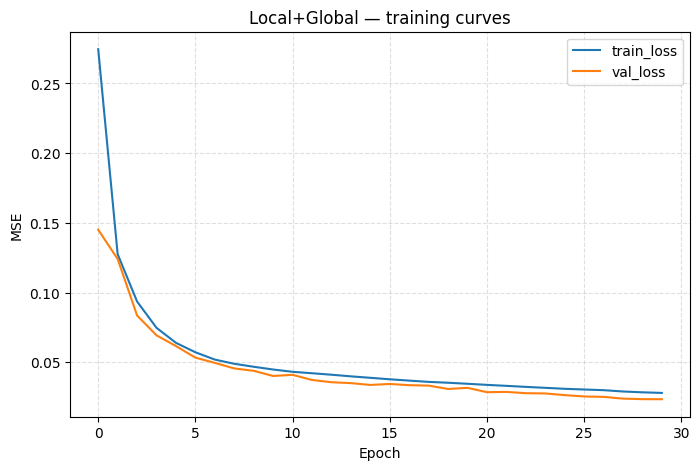

In [ ]:
# ---- training curves, drawn separately (each saved as its own 300 dpi jpg) ----

# (1) Local-only: train vs val
plt.figure(figsize=(8,5))
plt.plot(hist_local.history['loss'], label='train_loss')
plt.plot(hist_local.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Local-only — training curves')
plt.legend(); plt.grid(True, ls='--', alpha=.4)
plt.savefig('curves_local.jpg', dpi=300, bbox_inches='tight'); plt.show()

# (2) Local+Global: train vs val
plt.figure(figsize=(8,5))
plt.plot(hist_global.history['loss'], label='train_loss')
plt.plot(hist_global.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Local+Global — training curves')
plt.legend(); plt.grid(True, ls='--', alpha=.4)
plt.savefig('curves_global.jpg', dpi=300, bbox_inches='tight'); plt.show()



## 5. Results table — does global context help?

In [ ]:
def evaluate(model, ds, steps):
    mse, mae = model.evaluate(ds, steps=steps, verbose=0)
    return mse, mae

rows = []
for name, model, hist in [('Local-only', model_local, hist_local),
                          ('Local+Global', model_global, hist_global)]:
    v_mse, v_mae = evaluate(model, val_ds,  n_va)
    t_mse, t_mae = evaluate(model, test_ds, n_te)
    rows.append({'Model': name,
                 'Params': model.count_params(),
                 'best_val_MSE': min(hist.history['val_loss']),
                 'val_MSE': v_mse, 'val_MAE': v_mae,
                 'test_MSE': t_mse, 'test_MAE': t_mae})

results = pd.DataFrame(rows).set_index('Model').round(6)
results.to_csv('ablation_results.csv')
print(results.to_string())

              Params  best_val_MSE   val_MSE   val_MAE  test_MSE  test_MAE
Model                                                                     
Local-only     40649      0.021458  0.021539  0.081393  0.023368  0.084610
Local+Global   62185      0.023452  0.023657  0.084985  0.025503  0.088846


run this new cell to persist them to Drive

In [ ]:
import os
CKPT_DIR = '/content/drive/MyDrive/DL_Project_June/ckpts/'   # edit if your path differs
os.makedirs(CKPT_DIR, exist_ok=True)
model_local.save_weights(CKPT_DIR + 'atom_local.weights.h5')
model_global.save_weights(CKPT_DIR + 'atom_global.weights.h5')
print('Saved to Drive:', CKPT_DIR)

NameError: name 'model_local' is not defined

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

In [ ]:
CKPT_DIR = '/content/drive/MyDrive/DL_Project_June/ckpts/'
model_local  = build_model(use_global=False, sample_ds=train_ds)
model_local.load_weights(CKPT_DIR + 'atom_local.weights.h5')
model_global = build_model(use_global=True,  sample_ds=train_ds)
model_global.load_weights(CKPT_DIR + 'atom_global.weights.h5')
print('Reloaded trained models from Drive.')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (128, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 98 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Reloaded trained models from Drive.


## 7. Parametric sweep → **Table 1**  (≥3 HP configs × 2 time windows)

The project requires ≥3 hyper-parameter configurations and ≥2 time windows *per model*.
This section is fully parametric. Because a full sweep is heavy on free Colab, it is **guarded by
`RUN_FULL_SWEEP`** — leave it `False` to run a single quick demo config, flip it to `True` when you
have GPU budget. If you cannot finish the full grid, state this as a resource limitation in the
report and at the exam (the professor explicitly allowed this).

In [ ]:
# ===== Table 1 sweep (memory-safe) : 3 HP configs x 2 time windows, Transformer only =====
RUN_FULL_SWEEP = True
INCLUDE_LOCAL  = False

HP_CONFIGS = [
    dict(name='cfg1', num_layers=1, d_model=32, num_heads=2, dff=64,  lr=1e-4),
    dict(name='cfg2', num_layers=2, d_model=64, num_heads=4, dff=128, lr=1e-4),
    dict(name='cfg3', num_layers=2, d_model=32, num_heads=2, dff=64,  lr=5e-4),
]
TIME_WINDOWS   = [5, 10]
SWEEP_EPOCHS   = 8
N_ATOMS_SAMPLE = 2
STEPS_CAP      = 120
VAL_STEPS_CAP  = 25
TEST_STEPS_CAP = 40

# batch size shrinks as the window grows, so the global attention matrix fits in GPU memory
BATCH_BY_WINDOW = {5: 64, 10: 16}      # lower these further if you still OOM

DS_CACHE = {}
for tw in TIME_WINDOWS:
    bs = BATCH_BY_WINDOW.get(tw, 32)
    tr, va, te, ntr, nva, nte = build_datasets(tw, SPATIAL_WINDOW,
                                               batch_size=bs, n_atoms_sample=N_ATOMS_SAMPLE)
    DS_CACHE[tw] = (tr, va, te,
                    min(ntr, STEPS_CAP), min(nva, VAL_STEPS_CAP), min(nte, TEST_STEPS_CAP))

def run_config(use_global, t_window, hp):
    tr, va, te, ntr, nva, nte = DS_CACHE[t_window]
    m = build_model(use_global=use_global, num_layers=hp['num_layers'], d_model=hp['d_model'],
                    num_heads=hp['num_heads'], dff=hp['dff'], lr=hp['lr'], sample_ds=tr)
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                          restore_best_weights=True, verbose=0)
    h = m.fit(tr, validation_data=va, epochs=SWEEP_EPOCHS, steps_per_epoch=ntr,
              validation_steps=nva, callbacks=[es], verbose=0)
    t_mse, t_mae = m.evaluate(te, steps=nte, verbose=0)
    tf.keras.backend.clear_session()      # free GPU memory between runs
    return dict(variant='Global' if use_global else 'Local', window=t_window, config=hp['name'],
                params=m.count_params(), best_val_MSE=min(h.history['val_loss']),
                test_MSE=t_mse, test_MAE=t_mae)

variants = [True, False] if INCLUDE_LOCAL else [True]
records = []
for ug in variants:
    for tw in TIME_WINDOWS:
        for hp in HP_CONFIGS:
            print(f'>> {"Global" if ug else "Local"} | window={tw} | {hp["name"]}')
            records.append(run_config(ug, tw, hp))

table1 = pd.DataFrame(records).round(6)
table1.to_csv('table1_sweep.csv', index=False)
print(table1.to_string(index=False))

>> Global | window=5 | cfg1


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (64, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


>> Global | window=5 | cfg2


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (64, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


>> Global | window=5 | cfg3
>> Global | window=10 | cfg1


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (16, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


>> Global | window=10 | cfg2


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (16, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


>> Global | window=10 | cfg3
variant  window config  params  best_val_MSE  test_MSE  test_MAE
 Global       5   cfg1   62185      0.125309  0.161766  0.213604
 Global       5   cfg2  779209      0.071038  0.093860  0.174926
 Global       5   cfg3  117353      0.057111  0.073910  0.164351
 Global      10   cfg1   62185      0.124232  0.189598  0.235478
 Global      10   cfg2  779209      0.114063  0.179869  0.226577
 Global      10   cfg3  117353      0.108831  0.166412  0.213326


## 8. Exam inference cell  
*Loads the saved global model and runs one prediction on the test set (required by the rules).*

In [ ]:
import os
CKPT_DIR = '/content/drive/MyDrive/DL_Project_June/ckpts/'
os.makedirs(CKPT_DIR, exist_ok=True)
model_global.save_weights(CKPT_DIR + 'atom_global.weights.h5')
print('Saved.')

Saved.


In [ ]:
# ===== EXAM CELL: load model + run inference on test data =====
CKPT_DIR = '/content/drive/MyDrive/DL_Project_June/ckpts/'

def get_sample(features_arr, t, a, t_window, spatial_window):
    S = spatial_window
    padded = np.pad(features_arr, ((0,0),(S,S),(0,0)), mode='edge').astype(np.float32)
    x_enc  = padded[t-t_window:t, a:a+2*S+1, :].reshape(1, t_window, -1).astype(np.float32)
    x_dec  = features_arr[t, a, :].reshape(1, 1, -1).astype(np.float32)
    x_glob = features_arr[t-t_window:t].reshape(1, t_window, NUM_ATOMS, F).astype(np.float32)
    return x_enc, x_dec, x_glob

exam_model = build_model(use_global=True, sample_ds=test_ds)
exam_model.load_weights(CKPT_DIR + 'atom_global.weights.h5')
print('Loaded from', CKPT_DIR + 'atom_global.weights.h5')

t, a = T_WINDOW, 0
xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
current   = test_feat[t,   a, :]
true_next = test_feat[t+1, a, :]
pred_next = current + exam_model((xe, xd, xg), training=False).numpy()[0]

labels = ['x','y','z','vx','vy','vz','fx','fy','fz']
print(f'\n{"feat":<5}{"current":>11}{"true_next":>12}{"pred_next":>12}{"|err|":>10}')
print('-'*52)
for i, l in enumerate(labels):
    print(f'{l:<5}{current[i]:>11.5f}{true_next[i]:>12.5f}{pred_next[i]:>12.5f}'
          f'{abs(pred_next[i]-true_next[i]):>10.5f}')
print(f'\nOverall MAE (scaled): {np.mean(np.abs(pred_next-true_next)):.6f}')
print(f'Coord   MAE (scaled): {np.mean(np.abs(pred_next[:3]-true_next[:3])):.6f}')
print('Inference OK.')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (128, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Loaded from /content/drive/MyDrive/DL_Project_June/ckpts/atom_global.weights.h5

feat     current   true_next   pred_next     |err|
----------------------------------------------------
x       -3.70193    -3.70195    -3.69656   0.00540
y       -3.69180    -3.69164    -3.69281   0.00117
z       -3.58854    -3.58852    -3.58489   0.00363
vx      -0.20125    -0.02398    -0.03513   0.01114
vy       0.37074     0.45334     0.47190   0.01857
vz      -0.01424     0.04972     0.04636   0.00336
fx       1.30836     0.94578     1.22832   0.28254
fy       0.86747     0.94156     0.80502   0.13654
fz       0.37013     0.24535     0.43259   0.18724

Overall MAE (scaled): 0.072175
Coord   MAE (scaled): 0.003397
Inference OK.


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


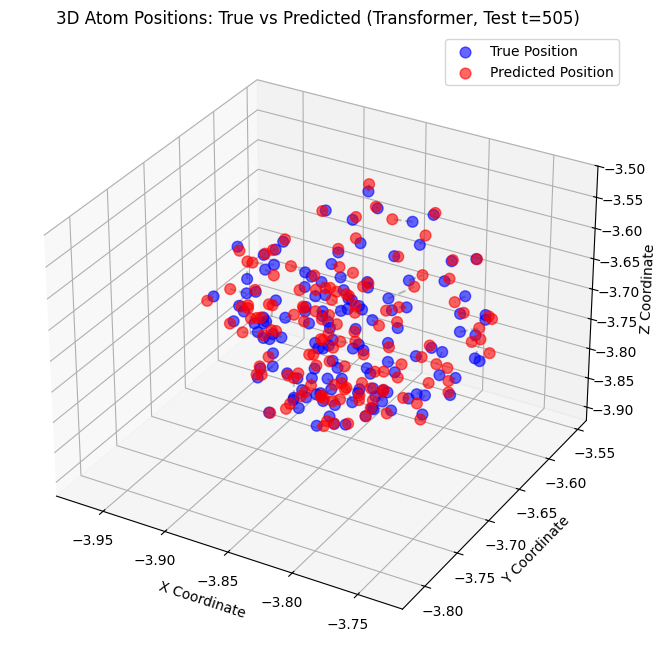

Mean |error| on X/Y/Z (scaled units): 0.00541


In [ ]:
# ===== 3D True vs Predicted atom positions (Transformer version) =====
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables 3d projection)

# 1. Pick a single time step to look at in the test set
sample_idx = T_WINDOW + 500          # must be >= T_WINDOW so a full window exists before it

# 2. Predict every atom's next state at this time step, one atom at a time
preds_frame = np.zeros((NUM_ATOMS, F), dtype=np.float32)
true_frame  = np.zeros((NUM_ATOMS, F), dtype=np.float32)

for a in range(NUM_ATOMS):
    xe, xd, xg = get_sample(test_feat, sample_idx, a, T_WINDOW, SPATIAL_WINDOW)
    current   = test_feat[sample_idx, a, :]
    delta     = model_global((xe, xd, xg), training=False).numpy()[0]
    preds_frame[a] = current + delta                      # reconstruct absolute predicted state
    true_frame[a]  = test_feat[sample_idx + 1, a, :]       # actual next state

# 3. Slice out X, Y, Z (first 3 columns) for all 138 atoms
preds_xyz = preds_frame[:, 0:3]
true_xyz  = true_frame[:, 0:3]

# 4. Set up the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(true_xyz[:, 0], true_xyz[:, 1], true_xyz[:, 2],
           c='blue', label='True Position', alpha=0.6, s=60)
ax.scatter(preds_xyz[:, 0], preds_xyz[:, 1], preds_xyz[:, 2],
           c='red', label='Predicted Position', alpha=0.6, s=60)

# 5. Error segments, true -> predicted, for every atom
for i in range(NUM_ATOMS):
    ax.plot([true_xyz[i, 0], preds_xyz[i, 0]],
            [true_xyz[i, 1], preds_xyz[i, 1]],
            [true_xyz[i, 2], preds_xyz[i, 2]],
            color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('Z Coordinate')
ax.set_title(f'3D Atom Positions: True vs Predicted (Transformer, Test t={sample_idx})')
plt.legend()
plt.savefig('pred_vs_true_3d.jpg', dpi=300, bbox_inches='tight')   # 300dpi jpg
plt.show()

mae_xyz = np.mean(np.abs(preds_xyz - true_xyz))
print(f'Mean |error| on X/Y/Z (scaled units): {mae_xyz:.5f}')

# Trajectory plot — a few atoms, their path over several steps

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


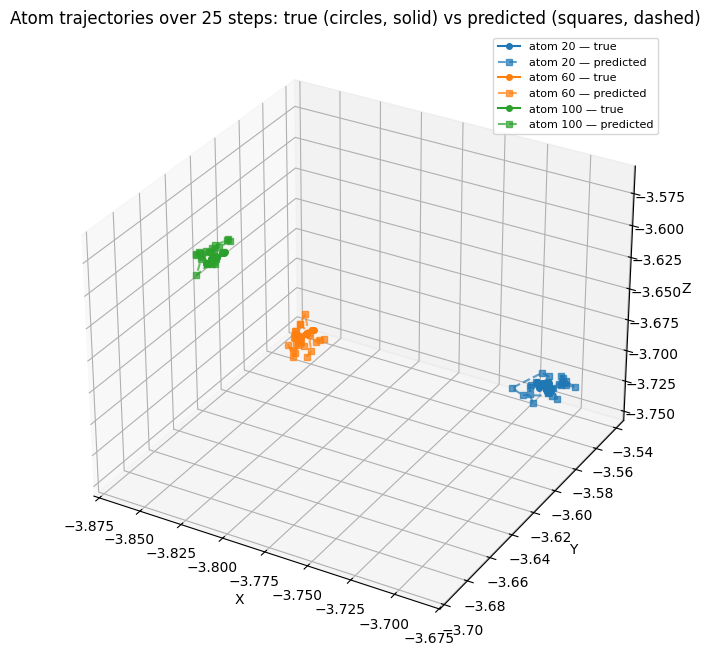

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

atoms_to_track = [20, 60, 100]     # a few representative atoms
K  = 25                            # consecutive timesteps to trace
t0 = T_WINDOW + 200                # start step (>= T_WINDOW)
model = model_local                # your better model (swap to model_global to compare)

fig = plt.figure(figsize=(11, 8)); ax = fig.add_subplot(111, projection='3d')
colors = plt.cm.tab10.colors

for j, a in enumerate(atoms_to_track):
    true_path, pred_path = np.zeros((K, 3)), np.zeros((K, 3))
    for k in range(K):
        t = t0 + k
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur   = test_feat[t, a, :3]
        delta = model((xe, xd, xg), training=False).numpy()[0][:3]
        pred_path[k] = cur + delta                 # predicted next position (one step ahead)
        true_path[k] = test_feat[t + 1, a, :3]     # actual next position
    c = colors[j % 10]
    ax.plot(*true_path.T, '-o', color=c, ms=4, label=f'atom {a} — true')
    ax.plot(*pred_path.T, '--s', color=c, ms=4, alpha=.7, label=f'atom {a} — predicted')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'Atom trajectories over {K} steps: true (circles, solid) vs predicted (squares, dashed)')
ax.legend(fontsize=8)
plt.savefig('trajectories_3d.jpg', dpi=300, bbox_inches='tight'); plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


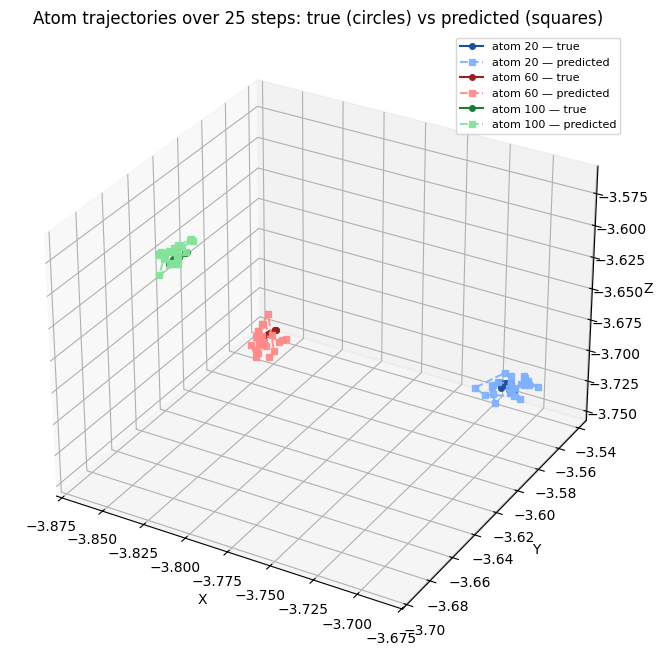

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

atoms_to_track = [20, 60, 100]     # a few representative atoms
K  = 25                            # consecutive timesteps to trace
t0 = T_WINDOW + 200                # start step (>= T_WINDOW)
model = model_local                # swap to model_global to compare

# one color-pair per atom: (true color, predicted color)
color_pairs = [
    ('#1f4e9c', '#7fb0ff'),   # atom 1: dark blue / light blue
    ('#9c1f1f', '#ff8a8a'),   # atom 2: dark red  / light red
    ('#1f7a34', '#84e29a'),   # atom 3: dark green/ light green
    ('#7a3f1f', '#e0a877'),   # atom 4: brown pair (if you add more atoms)
    ('#5a1f7a', '#c79ae0'),   # atom 5: purple pair
]

fig = plt.figure(figsize=(11, 8)); ax = fig.add_subplot(111, projection='3d')

for j, a in enumerate(atoms_to_track):
    true_path, pred_path = np.zeros((K, 3)), np.zeros((K, 3))
    for k in range(K):
        t = t0 + k
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur   = test_feat[t, a, :3]
        delta = model((xe, xd, xg), training=False).numpy()[0][:3]
        pred_path[k] = cur + delta                 # predicted next position (one step ahead)
        true_path[k] = test_feat[t + 1, a, :3]     # actual next position
    c_true, c_pred = color_pairs[j % len(color_pairs)]
    ax.plot(*true_path.T, '-o',  color=c_true, ms=4,          label=f'atom {a} — true')
    ax.plot(*pred_path.T, '--s', color=c_pred, ms=4, alpha=.9, label=f'atom {a} — predicted')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title(f'Atom trajectories over {K} steps: true (circles) vs predicted (squares)')
ax.legend(fontsize=8)
plt.savefig('trajectories_3d.jpg', dpi=300, bbox_inches='tight'); plt.show()

# Animation — full cloud over time, saved as a GIF so it plays in Colab:

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


saved molecule_evolution.gif


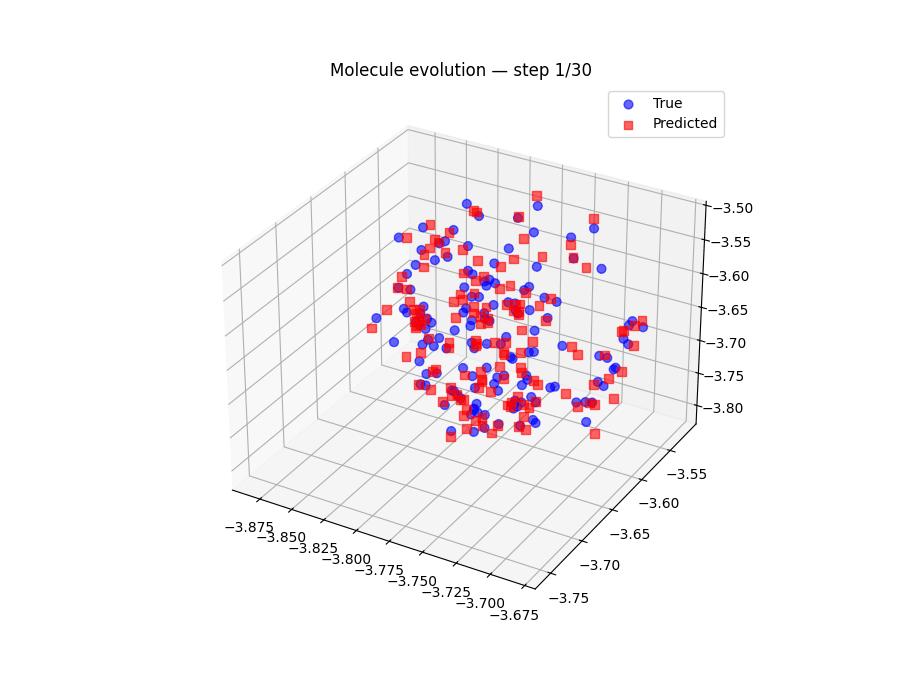

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

N_FRAMES = 30
t0 = T_WINDOW + 200
model = model_local

true_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
pred_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
for f in range(N_FRAMES):                 # ~1–2 min on GPU (138 atoms × 30 frames)
    t = t0 + f
    for a in range(NUM_ATOMS):
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur = test_feat[t, a, :3]
        d   = model((xe, xd, xg), training=False).numpy()[0][:3]
        pred_frames[f, a] = cur + d
        true_frames[f, a] = test_feat[t + 1, a, :3]

lims = [(true_frames[..., i].min(), true_frames[..., i].max()) for i in range(3)]
fig = plt.figure(figsize=(9, 7)); ax = fig.add_subplot(111, projection='3d')

def update(f):
    ax.clear()
    ax.scatter(*true_frames[f].T, c='blue', marker='o', alpha=.6, s=40, label='True')
    ax.scatter(*pred_frames[f].T, c='red',  marker='s', alpha=.6, s=40, label='Predicted')
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.set_title(f'Molecule evolution — step {f+1}/{N_FRAMES}'); ax.legend(loc='upper right')

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=200)
anim.save('molecule_evolution.gif', writer=PillowWriter(fps=5), dpi=100)
plt.close()
print('saved molecule_evolution.gif')

# show it inline in Colab
from IPython.display import Image
Image(filename='molecule_evolution.gif')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


saved molecule_evolution.gif


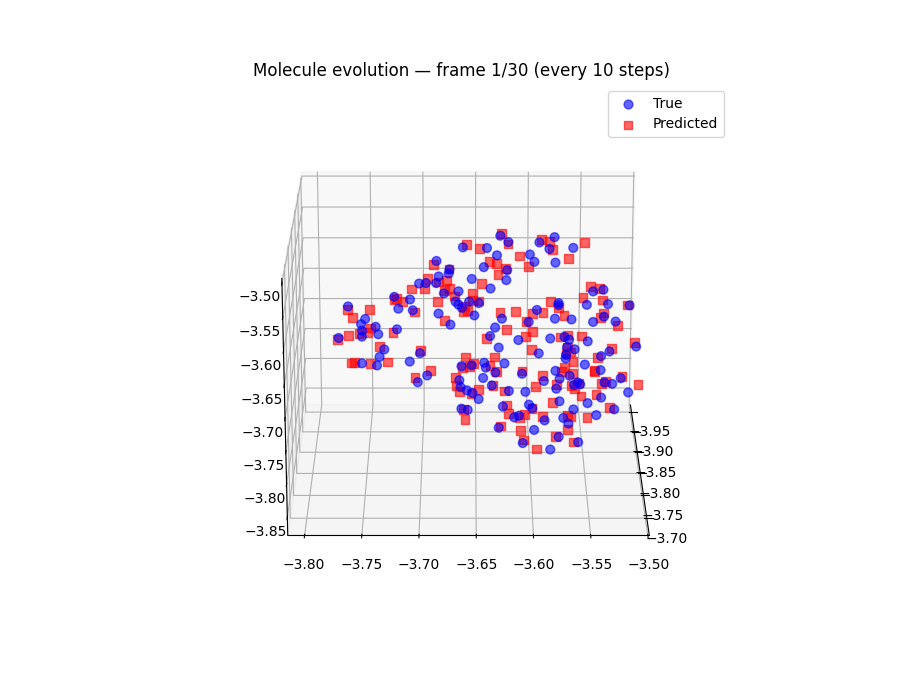

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

N_FRAMES = 30
STRIDE   = 10                 # <-- skip steps so motion between frames is larger
t0 = T_WINDOW + 200
model = model_local

true_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
pred_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
for f in range(N_FRAMES):
    t = t0 + f * STRIDE
    for a in range(NUM_ATOMS):
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur = test_feat[t, a, :3]
        d   = model((xe, xd, xg), training=False).numpy()[0][:3]
        pred_frames[f, a] = cur + d
        true_frames[f, a] = test_feat[t + 1, a, :3]

# limits from BOTH clouds so nothing clips at the edges
allpts = np.concatenate([true_frames, pred_frames], axis=0)
lims = [(allpts[..., i].min(), allpts[..., i].max()) for i in range(3)]

fig = plt.figure(figsize=(9, 7)); ax = fig.add_subplot(111, projection='3d')
def update(f):
    ax.clear()
    ax.scatter(*true_frames[f].T, c='blue', marker='o', alpha=.6, s=40, label='True')
    ax.scatter(*pred_frames[f].T, c='red',  marker='s', alpha=.6, s=40, label='Predicted')
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.view_init(elev=20, azim=f * 4)        # <-- slow rotation
    ax.set_title(f'Molecule evolution — frame {f+1}/{N_FRAMES} (every {STRIDE} steps)')
    ax.legend(loc='upper right')

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=200)
anim.save('molecule_evolution.gif', writer=PillowWriter(fps=5), dpi=100)
plt.close(); print('saved molecule_evolution.gif')
from IPython.display import Image
Image(filename='molecule_evolution.gif')

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


saved molecule_evolution.gif


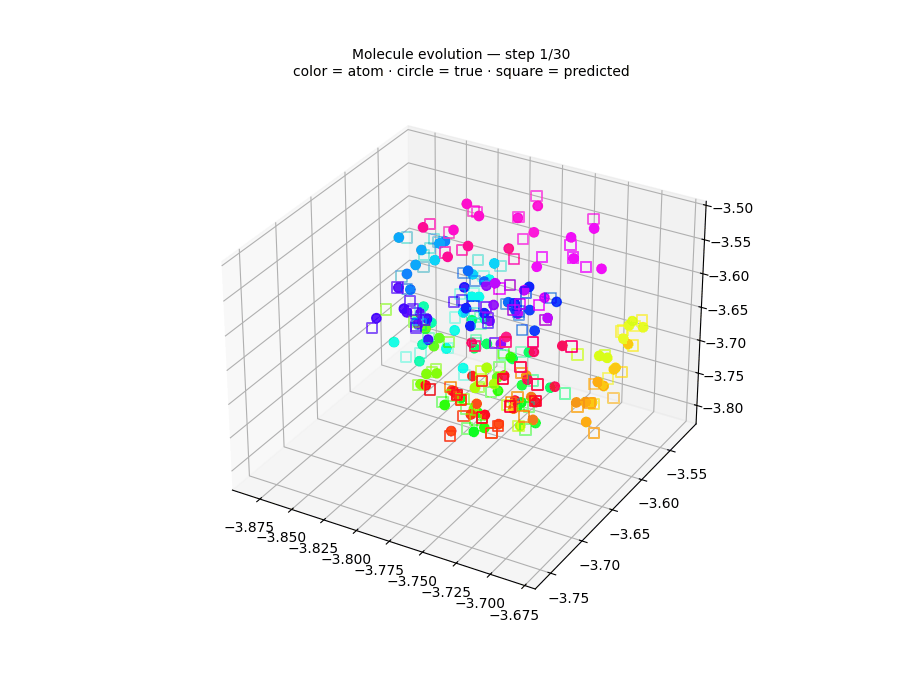

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D

N_FRAMES = 30
t0 = T_WINDOW + 200
model = model_local

true_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
pred_frames = np.zeros((N_FRAMES, NUM_ATOMS, 3))
for f in range(N_FRAMES):
    t = t0 + f
    for a in range(NUM_ATOMS):
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur = test_feat[t, a, :3]
        d   = model((xe, xd, xg), training=False).numpy()[0][:3]
        pred_frames[f, a] = cur + d
        true_frames[f, a] = test_feat[t + 1, a, :3]

# one fixed color per atom, reused every frame
atom_colors = plt.cm.hsv(np.linspace(0, 1, NUM_ATOMS))

lims = [(true_frames[..., i].min(), true_frames[..., i].max()) for i in range(3)]
fig = plt.figure(figsize=(9, 7)); ax = fig.add_subplot(111, projection='3d')

def update(f):
    ax.clear()
    # true = filled circles, predicted = hollow squares, same color per atom
    ax.scatter(*true_frames[f].T, c=atom_colors, marker='o', s=45, alpha=.9)
    ax.scatter(*pred_frames[f].T, facecolors='none', edgecolors=atom_colors,
               marker='s', s=55, linewidths=1.3)
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.set_title(f'Molecule evolution — step {f+1}/{N_FRAMES}\n'
                 f'color = atom · circle = true · square = predicted', fontsize=10)

anim = FuncAnimation(fig, update, frames=N_FRAMES, interval=200)
anim.save('molecule_evolution.gif', writer=PillowWriter(fps=5), dpi=100)
plt.close(); print('saved molecule_evolution.gif')

from IPython.display import Image
Image(filename='molecule_evolution.gif')

Try s.th like Vin

In [ ]:
import numpy as np

N_STEPS = 100          # fewer steps too, since you're on CPU
STRIDE  = 2            # skip steps so you still cover a decent time span
t0      = T_WINDOW
model   = model_local
S       = SPATIAL_WINDOW

preds_xyz_all = np.zeros((N_STEPS, NUM_ATOMS, 3), dtype=np.float32)
true_xyz_all  = np.zeros((N_STEPS, NUM_ATOMS, 3), dtype=np.float32)

for f in range(N_STEPS):
    t = t0 + f * STRIDE
    padded = np.pad(test_feat, ((0,0),(S,S),(0,0)), mode='edge').astype(np.float32)

    # build all 138 atoms' inputs at once
    xe = np.stack([padded[t-T_WINDOW:t, a:a+2*S+1, :].reshape(T_WINDOW, -1)
                   for a in range(NUM_ATOMS)]).astype(np.float32)      # (138, T, 189)
    xd = test_feat[t, :, :].reshape(NUM_ATOMS, 1, -1).astype(np.float32)  # (138, 1, 9)
    xg = np.repeat(test_feat[t-T_WINDOW:t][None], NUM_ATOMS, axis=0).astype(np.float32)  # (138, T, 138, 9)

    deltas = model((xe, xd, xg), training=False).numpy()[:, :3]        # ONE call for all atoms
    preds_xyz_all[f] = test_feat[t, :, :3] + deltas
    true_xyz_all[f]  = test_feat[t + STRIDE if False else t+1, :, :3]

inv = lambda arr: arr * scaler.scale_[:3] + scaler.mean_[:3]
preds_xyz_all, true_xyz_all = inv(preds_xyz_all), inv(true_xyz_all)
print('done:', preds_xyz_all.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (138, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


done: (100, 138, 3)


In [ ]:
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
import ipywidgets as widgets
from IPython.display import display

diff       = preds_xyz_all - true_xyz_all
distances  = np.linalg.norm(diff, axis=2)
true_norms = np.linalg.norm(true_xyz_all, axis=2)
true_norms[true_norms == 0] = 1e-8
percentage_errors = (distances.sum(1) / true_norms.sum(1)) * 100

# --- fixed axis limits ---
allpts = np.concatenate([true_xyz_all, preds_xyz_all], axis=0)
lims = [(allpts[..., i].min(), allpts[..., i].max()) for i in range(3)]

N = true_xyz_all.shape[0]

def show_frame(t):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    ct, cp = true_xyz_all[t], preds_xyz_all[t]
    ax.scatter(*ct.T, c='blue', marker='o', s=40, alpha=.6, label='True')
    ax.scatter(*cp.T, c='red',  marker='s', s=40, alpha=.6, label='Predicted')
    for i in range(true_xyz_all.shape[1]):
        ax.plot([ct[i,0],cp[i,0]], [ct[i,1],cp[i,1]], [ct[i,2],cp[i,2]],
                color='gray', ls='--', alpha=.4)
    ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Timestamp {t}  |  Overall error: {percentage_errors[t]:.2f}%')
    ax.legend(loc='upper left')
    plt.show()

widgets.interact(show_frame,
                 t=widgets.IntSlider(min=0, max=N-1, step=1, value=0,
                                     description='Timestamp'))

interactive(children=(IntSlider(value=0, description='Timestamp', max=99), Output()), _dom_classes=('widget-in…

<function __main__.show_frame(t)>

# As Vin local
in Colab: build the arrays from your transformer and save the .npz

In [ ]:
import numpy as np
from google.colab import files

# how many timestamps to export for the slider
N_STEPS = 100                      # raise/lower as you like
t0      = T_WINDOW                 # first valid step
model   = model_local              # your better model (or model_global to compare)

preds_xyz_all = np.zeros((N_STEPS, NUM_ATOMS, 3), dtype=np.float32)
true_xyz_all  = np.zeros((N_STEPS, NUM_ATOMS, 3), dtype=np.float32)

for f in range(N_STEPS):
    t = t0 + f
    for a in range(NUM_ATOMS):
        xe, xd, xg = get_sample(test_feat, t, a, T_WINDOW, SPATIAL_WINDOW)
        cur = test_feat[t, a, :3]
        d   = model((xe, xd, xg), training=False).numpy()[0][:3]
        preds_xyz_all[f, a] = cur + d
        true_xyz_all[f, a]  = test_feat[t + 1, a, :3]

# (optional but recommended) convert scaled coords back to original physical units
# so the error % and axes mean something real. coords are the first 3 of 9 features:
inv = lambda arr: arr * scaler.scale_[:3] + scaler.mean_[:3]
preds_xyz_all = inv(preds_xyz_all)
true_xyz_all  = inv(true_xyz_all)

filename = 'protein_dynamics_data.npz'
np.savez_compressed(filename, preds=preds_xyz_all, true_vals=true_xyz_all)
print(f"Saved {filename}  shape preds={preds_xyz_all.shape}")
files.download(filename)   # downloads to your computer

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (1, 2, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


Saved protein_dynamics_data.npz  shape preds=(100, 138, 3)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>